In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

import h5py

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

def triplet(op):                      
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [2]:
# with open('configs/beta_4_m0_0.0_Nx_4_Nt_32_melted.pkl', 'rb') as f:
#     Nx4 = pickle.load(f)

# sim.distillation.generateDistillFile(modelObj=Nx4,filePath='configs/beta_4_m0_0.0_Nx_4_Nt_32_melted.hdf5',numVecs=3,autocorrSkip=25,DNums=(0,1,2),momks=(0,1,2))

In [3]:
pathNx4  = "configs/beta_4_m0_0.0_Nx_4_Nt_32_melted.hdf5"
pathNx8  = "configs/beta_4_m0_0.0_Nx_8_Nt_32_melted.hdf5"
pathNx16 = "configs/beta_4_m0_0.0_Nx_16_Nt_32_melted.hdf5"
pathNx32 = "configs/beta_4_m0_0.0_Nx_32_Nt_32_melted.hdf5"

Nx4_meta = sim.distillation.readDistillMeta(pathNx4)
Nx8_meta = sim.distillation.readDistillMeta(pathNx8)
Nx16_meta = sim.distillation.readDistillMeta(pathNx16)
Nx32_meta = sim.distillation.readDistillMeta(pathNx32)

In [4]:
pionBasis = [triplet(MesonOp("g5")),triplet(MesonOp("g5",DNum=2))]

In [5]:
pionCorrels_Nx4 = sim.GEVP.measureEnsemble(pathNx4,(Nx4_meta.configIndices),pionBasis)
pionCorrels_Nx8 = sim.GEVP.measureEnsemble(pathNx8,(Nx8_meta.configIndices),pionBasis)
pionCorrels_Nx16 = sim.GEVP.measureEnsemble(pathNx16,(Nx16_meta.configIndices),pionBasis)
pionCorrels_Nx32 = sim.GEVP.measureEnsemble(pathNx32,(Nx32_meta.configIndices),pionBasis)

Measuring configs: 100%|██████████| 1000/1000 [00:02<00:00, 407.54it/s]


In [6]:
gevpTi = 2
pionPrinCorrels_Nx4 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx4, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
pionPrinCorrels_Nx8 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx8, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
pionPrinCorrels_Nx16 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx16, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
pionPrinCorrels_Nx32 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx32, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [7]:
pionMass_Nx4 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx4,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,6], withAmp=True))
pionMass_Nx8 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx8,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,6], withAmp=True))
pionMass_Nx16 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx16,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,6], withAmp=True))
pionMass_Nx32 = sim.GEVP.bootstrapEnsemble(pionCorrels_Nx32,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,6], withAmp=True))

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 0% (components failing >5%: 0)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "


In [8]:
def rgb_to_hex(rgb):
    return "#%02x%02x%02x" % rgb

# Main JLab palette
JLab_red    = rgb_to_hex((192, 39, 45))
JLab_orange = rgb_to_hex((249, 102, 0))
JLab_blue   = rgb_to_hex((47, 122, 121))
JLab_green  = rgb_to_hex((65, 125, 10))

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",          # Computer Modern math, matches the papers
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.6,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# color, marker per volume (marker shape doubles the color, for CVD safety)
nxStyle = {
    4:  (JLab_red,    "o"),
    8:  (JLab_orange, "s"),
    16: (JLab_blue,   "D"),
    32: (JLab_green,  "^"),
}
eb_kw = dict(ms=9, mfc="white", mew=2.2, elinewidth=2.2, capsize=4,
             capthick=2.2, ls="none", zorder=3)

prinCorrels = {4: pionPrinCorrels_Nx4, 8: pionPrinCorrels_Nx8,
               16: pionPrinCorrels_Nx16, 32: pionPrinCorrels_Nx32}
masses      = {4: pionMass_Nx4, 8: pionMass_Nx8,
               16: pionMass_Nx16, 32: pionMass_Nx32}
fitT = [2, 6]

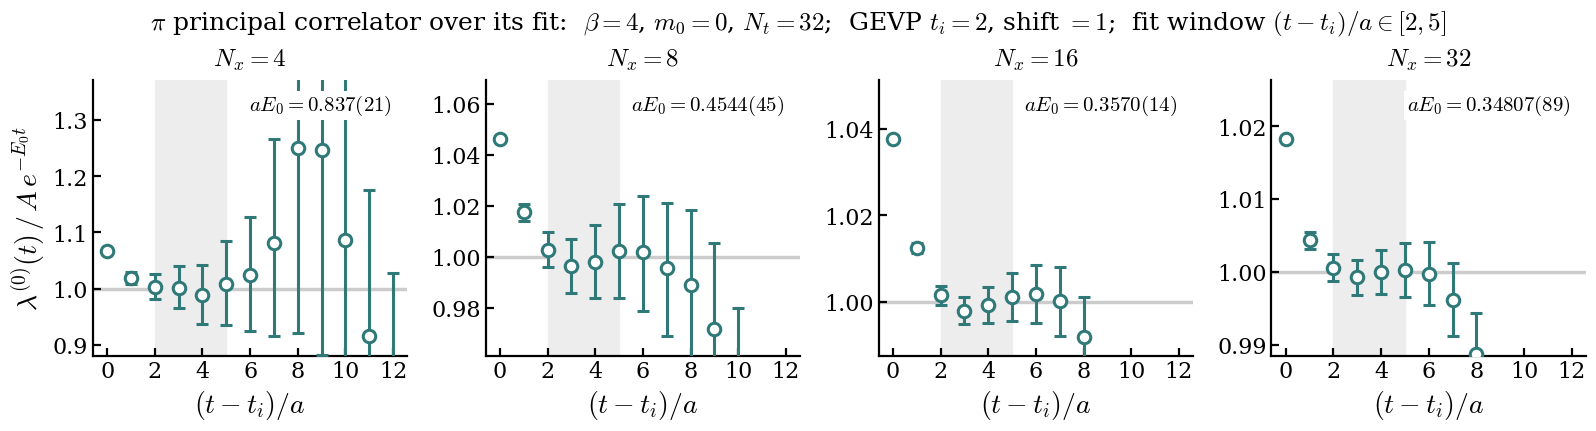

In [9]:
# Ground-state principal correlator divided by its exponential fit, one panel
# per volume: lambda(t) / (A e^{-E t}) -> 1 inside the fit window (grey band).
state = 0
tmax = 13

def fmtErr(v, e):
    """0.7871(12)-style value with parenthesized error (2 sig figs)."""
    if not np.isfinite(e) or e <= 0:
        return f"{v:.4f}"
    ndig = max(-int(np.floor(np.log10(e))) + 1, 0)
    return f"{v:.{ndig}f}({round(e * 10**ndig):d})"

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), layout="constrained")
fig.get_layout_engine().set(w_pad=0.12)

for ax, Nx in zip(axes, nxStyle):
    central, err, _ = prinCorrels[Nx]
    E, logA = masses[Nx][0][state]                # massReduce withAmp: [E, logA]
    dE = np.nanmax(masses[Nx][1][:, state, 0])
    t = np.arange(central.shape[0])               # curve-index time, matches the fit
    fit = np.exp(logA - E * t)
    sel = t < tmax

    ax.axhline(1.0, color="0.8", lw=2.5, zorder=0)
    ax.axvspan(fitT[0], fitT[1] - 1, color="0.93", zorder=0)   # fit window

    ratio = (central[:, state] / fit)[sel]
    # err rows are [high-central, central-low]; matplotlib wants [lower, upper].
    # negative err = central outside its own bootstrap band (bias at noisy t);
    # clip that side to zero so the marker still shows the central value
    errUp, errDn = np.clip(err[:, sel, state], 0.0, None) / fit[sel]
    ax.errorbar(t[sel], ratio, yerr=[errDn, errUp],
                marker="o", color=JLab_blue, mec=JLab_blue, **eb_kw)

    # y-range from the error band around the fit region (late-time noise would
    # otherwise dominate the autoscale), with headroom for the aE0 label
    focus = t[sel] <= fitT[1] + 1
    lo = np.nanmin((ratio - errDn)[focus])
    hi = np.nanmax((ratio + errUp)[focus])
    pad = 0.10 * (hi - lo)
    ax.set_ylim(lo - pad, hi + 3.0 * pad)

    ax.set_title(rf"$N_x = {Nx}$", fontsize=18, pad=10)
    ax.text(0.95, 0.95, rf"$aE_0 = {fmtErr(E, dE)}$",
            ha="right", va="top", transform=ax.transAxes, fontsize=15,
            zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=2))
    ax.set_xlim(-0.6, tmax - 0.4)
    ax.set_xticks(range(0, tmax, 2))
    ax.set_xlabel(r"$(t - t_i)/a$")

axes[0].set_ylabel(r"$\lambda^{(0)}(t) \, / \, A\,e^{-E_0 t}$")
fig.suptitle(r"$\pi$ principal correlator over its fit:  $\beta = 4$, $m_0 = 0$, "
             r"$N_t = 32$;  GEVP $t_i = 2$, shift $= 1$;  fit window "
             rf"$(t - t_i)/a \in [{fitT[0]}, {fitT[1] - 1}]$", fontsize=18)

fig.savefig("figs/pionPrinCorrelOverFit_beta4_Nx4-32.pdf")
plt.show()

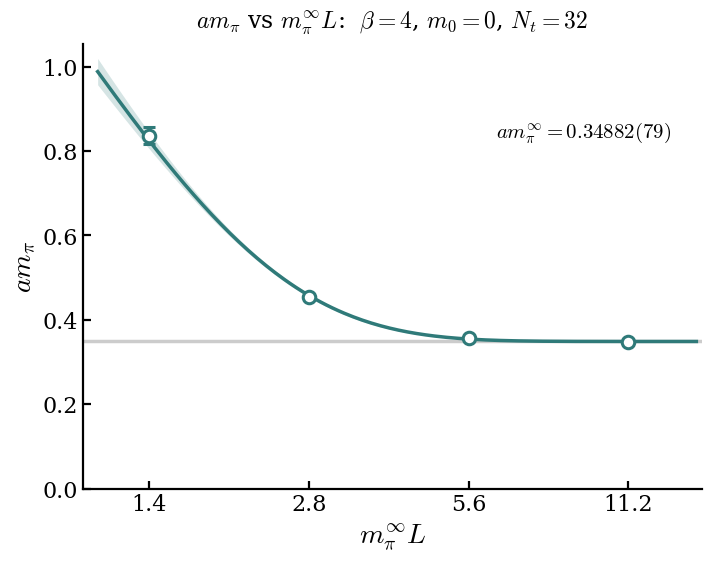

In [11]:
# Fitted ground-state mass vs mpi*L, with an exponential finite-volume fit
# m(Nx) = m_inf + A exp(-B Nx); the axis uses the fitted infinite-volume mass.
from scipy.optimize import curve_fit

nxs  = np.array(list(nxStyle))
mVal = np.array([masses[Nx][0][0, 0] for Nx in nxs])
# err rows are [high-central, central-low]; matplotlib wants [lower, upper]
mErr = np.clip(np.array([masses[Nx][1][:, 0, 0] for Nx in nxs]).T, 0.0, None)
mSig = mErr.mean(axis=0)                          # symmetrized error for the fit

def fvExp(Nx, mInf, A, B):
    return mInf + A * np.exp(-B * Nx)

p0 = [mVal[-1], mVal[0] - mVal[-1], 0.3]
popt, pcov = curve_fit(fvExp, nxs, mVal, p0=p0, sigma=mSig, absolute_sigma=True)
mInf, dmInf = popt[0], np.sqrt(pcov[0, 0])

xs = np.geomspace(3.2, 43, 200)                   # in Nx units; axis = mInf * Nx
J = np.stack([np.ones_like(xs), np.exp(-popt[2] * xs),
              -popt[1] * xs * np.exp(-popt[2] * xs)])
band = np.sqrt(np.einsum("ix,ij,jx->x", J, pcov, J))

fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")

ax.axhline(mInf, color="0.8", lw=2.5, zorder=0)   # fitted infinite-volume mass
ax.fill_between(mInf * xs, fvExp(xs, *popt) - band, fvExp(xs, *popt) + band,
                color=JLab_blue, alpha=0.20, lw=0, zorder=1)
ax.plot(mInf * xs, fvExp(xs, *popt), color=JLab_blue, lw=2.5, zorder=2)

ax.errorbar(mInf * nxs, mVal, yerr=mErr[::-1],
            marker="o", color=JLab_blue, mec=JLab_blue, **eb_kw)

ax.text(0.95, 0.83, rf"$am_\pi^\infty = {fmtErr(mInf, dmInf)}$",
        ha="right", va="top", transform=ax.transAxes, fontsize=15,
        zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=2))

ax.set_xscale("log", base=2)
ax.set_xticks(mInf * nxs, labels=[f"{x:.1f}" for x in mInf * nxs])
ax.minorticks_off()
ax.set_xlabel(r"$m_\pi^\infty L$")
ax.set_ylabel(r"$a m_\pi$")
ax.set_xlim(mInf * 3, mInf * 44)
ax.set_ylim(bottom=0.0)

meta = Nx32_meta                                  # beta=4 not stored in the hdf5 attrs
ax.set_title(rf"$am_\pi$ vs $m_\pi^\infty L$:  $\beta = 4$, $m_0 = {meta.fMass:g}$, "
             rf"$N_t = {meta.dimt}$", fontsize=17, pad=12)

fig.savefig("figs/pionMassVsMpiL_beta4_Nt32.pdf")
plt.show()